# Exploratory phylogenetic path analysis

**Exact TE34 ∩ Cell21 ∩ tree panel (path18, n = 18)**

This is a collaborator-review notebook. It loads frozen data, figures, manifests,
and trees and can link to optional local HTML review pages; it does not rerun
expensive bioinformatics, segmentation, model training, or path-model fitting.
Every result is identified by its analysis panel and exact source path.

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
from IPython.display import HTML, IFrame, Image, Markdown, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "path_analysis/data/derived").exists() and (candidate / "scripts/processing").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Open this notebook from inside the Desmognathus_TE repository")

REVIEW_FIGURE_DIR = ROOT / "results/figures/research_review"
REVIEW_DATA_DIR = ROOT / "results/data/research_review"
FROZEN_INPUT_DIR = REVIEW_DATA_DIR / "frozen_inputs"
FROZEN_REGISTRY_PATH = REVIEW_DATA_DIR / "frozen_input_registry.csv"
FIGURE_BUILD_COMMAND = 'scripts/run_in_dusky.sh Rscript scripts/processing/build_audited_historical_style_figures.R'

if not FROZEN_REGISTRY_PATH.exists():
    raise FileNotFoundError(
        f"Portable dependency registry missing: {FROZEN_REGISTRY_PATH}. "
        "Rebuild the research-review notebooks first."
    )
frozen_registry = pd.read_csv(FROZEN_REGISTRY_PATH)
required_registry_columns = {"source_path", "frozen_path", "source_sha256", "frozen_sha256"}
if not required_registry_columns.issubset(frozen_registry.columns):
    raise RuntimeError("Frozen dependency registry schema is incomplete")
if not frozen_registry.source_sha256.eq(frozen_registry.frozen_sha256).all():
    raise RuntimeError("Frozen dependency registry contains a source/snapshot hash mismatch")
FROZEN_ARTIFACTS = dict(zip(frozen_registry.source_path, frozen_registry.frozen_path))

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

missing_snapshots = [path for path in frozen_registry.frozen_path if not (ROOT / path).exists()]
if missing_snapshots:
    raise FileNotFoundError(f"Portable dependency snapshots missing: {missing_snapshots}")
corrupt_snapshots = [
    row.frozen_path
    for row in frozen_registry.itertuples()
    if file_sha256(ROOT / row.frozen_path) != row.frozen_sha256
]
if corrupt_snapshots:
    raise RuntimeError(f"Portable dependency snapshot SHA256 mismatch: {corrupt_snapshots}")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 120)

def resolve_artifact(relative):
    path = Path(relative)
    if path.is_absolute():
        return path
    return ROOT / FROZEN_ARTIFACTS.get(str(relative), str(relative))

def read_csv(relative, **kwargs):
    path = resolve_artifact(relative)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def require_paths(paths, build_command=None):
    missing = [str(path) for path in paths if not Path(path).exists()]
    if missing:
        message = "Missing required frozen review artifacts:\n- " + "\n- ".join(missing)
        if build_command:
            message += f"\n\nGenerate only the lightweight review outputs with:\n{build_command}"
        raise FileNotFoundError(message)

def show_figure(relative, width=1150):
    path = resolve_artifact(relative)
    require_paths([path])
    display(Image(filename=str(path), width=width))

def show_text(relative, language="text", max_chars=16000):
    path = resolve_artifact(relative)
    require_paths([path])
    text = path.read_text(errors="replace")
    if len(text) > max_chars:
        text = text[:max_chars] + "\n... [display truncated; open the linked source for the complete file]"
    display(Markdown(f"```{language}\n{text}\n```"))

def artifact_table(relatives):
    rows = []
    for relative in relatives:
        path = resolve_artifact(relative)
        rows.append({
            "artifact": relative,
            "frozen_artifact": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024**2, 3) if path.exists() else np.nan,
        })
    result = pd.DataFrame(rows)
    if not result.exists.all():
        raise FileNotFoundError(result.loc[~result.exists, "artifact"].tolist())
    return result

print(f"Repository: {ROOT}")
print("Mode: frozen-artifact review only; no expensive upstream analysis is run")
print(f"Portable dependency snapshots: {len(frozen_registry)}")

Repository: /home/jake/Projects/Desmognathus_TE
Mode: frozen-artifact review only; no expensive upstream analysis is run
Portable dependency snapshots: 90


## Inferential boundary

The models compare a small set of biological DAGs on the exact 18-species overlap.
They use relative nuclear-IOD, not absolute genome size. Candidate models were
formalized after historical results existed, so this is exploratory phylogenetic
path analysis—not prospectively confirmatory causal identification.

In [2]:
panel = read_csv("path_analysis/data/derived/panels/study_integrated_path_panel18_v1.csv")
inputs = read_csv("results/data/corrected/path_analysis/corrected_path_input_sensitivity_analysis18_v1.csv")
specifications = read_csv("results/data/corrected/path_analysis/corrected_path_measurement_specifications_analysis18_v1.csv")
assert len(panel) == 18 and panel.species.is_unique
assert set(inputs.species) == set(panel.species)
assert "genome_size_pg" not in inputs.columns
display(specifications)
display(inputs.head(36))

,morphology_estimator,estimator_label,iod_subset,n_species,n_species_with_terminal_internal_proxy,minimum_morphology_specimens,total_manual_keeps,total_model_ranked_unlabeled,absolute_genome_size_used,confirmatory_claim_allowed
0,composite_selected50,Frozen composite top 50,all_selected,18,16,1,324,574,False,False
1,composite_selected50,Frozen composite top 50,high_qc,18,16,1,324,574,False,False
2,composite_selected50,Frozen composite top 50,image_qc_pass,18,16,1,324,574,False,False
3,eligible_candidate_pool,All eligible candidates,all_selected,18,16,1,324,574,False,False
4,eligible_candidate_pool,All eligible candidates,high_qc,18,16,1,324,574,False,False
5,eligible_candidate_pool,All eligible candidates,image_qc_pass,18,16,1,324,574,False,False
6,image_balanced_selected50,Equal-image frozen top 50,all_selected,18,16,1,324,574,False,False
7,image_balanced_selected50,Equal-image frozen top 50,high_qc,18,16,1,324,574,False,False
8,image_balanced_selected50,Equal-image frozen top 50,image_qc_pass,18,16,1,324,574,False,False
9,literal_largest100_eligible,Literal largest 100,all_selected,18,16,1,324,574,False,False


,species,morphology_estimator,estimator_label,cell_area_um2,nc_area_ratio,nuc_area_um2,iod_subset,relative_nuclear_iod_proxy,iod_n_images,iod_n_specimens,iod_n_pass_images,iod_n_high_qc_nuclei,iod_proxy_is_absolute_genome_size,DIRS,Helitron,LINE,LTR,Maverick,PLE,SINE,TIR,Transposon Derivatives,YR,ltr_line_logratio,observed_richness,shannon_entropy,gini_simpson,hill_q1,hill_q2,pielou_evenness,ectopic_n_elements,terminal_internal_ratio_median,terminal_internal_ratio_geometric_mean,terminal_internal_ratio_median_ci_low,terminal_internal_ratio_median_ci_high,morphology_n_images,morphology_n_specimens,n_manual_keep,n_model_ranked_unlabeled,manual_keep_fraction,terminal_internal_proxy_is_ectopic_rate,analysis_interpretation
0,amphileucus,composite_selected50,Frozen composite top 50,297.1296,0.139244,41.6592,all_selected,0.936665,2,2,1,15,False,0.024704,0.003090,0.157981,0.598473,0.003710,0.000101,0.011972,0.195846,0.002641,0.001483,1.331904,10,1.127359,0.577731,3.087492,2.368156,0.489606,25.0,0.727768,0.741610,0.574792,0.868127,2,2,27,23,0.54,False,exploratory_measurement_sensitivity
1,anicetus,composite_selected50,Frozen composite top 50,232.8408,0.171142,39.2904,all_selected,0.829251,1,1,1,8,False,0.018179,0.001770,0.178904,0.602212,0.002538,0.000058,0.012443,0.180070,0.002109,0.001716,1.213762,10,1.100317,0.572407,3.005117,2.338673,0.477861,26.0,0.568909,0.598937,0.487563,0.806865,1,1,38,12,0.76,False,exploratory_measurement_sensitivity
2,apalachicolae,composite_selected50,Frozen composite top 50,268.6536,0.146630,40.5576,all_selected,0.874993,2,2,1,11,False,0.016645,0.001646,0.177888,0.613098,0.003156,0.000076,0.010076,0.173680,0.002093,0.001642,1.237374,10,1.078505,0.561903,2.940279,2.282602,0.468389,12.0,0.580343,0.544045,0.372910,0.878056,2,2,26,24,0.52,False,exploratory_measurement_sensitivity
3,auriculatus,composite_selected50,Frozen composite top 50,282.8232,0.166984,47.2392,all_selected,0.924163,2,2,1,6,False,0.010942,0.001127,0.152588,0.647548,0.005883,0.000038,0.007261,0.171694,0.001881,0.001038,1.445454,10,1.013151,0.527706,2.754265,2.117326,0.440006,13.0,0.709443,0.674012,0.448303,1.030496,2,2,26,24,0.52,False,exploratory_measurement_sensitivity
4,bairdi,composite_selected50,Frozen composite top 50,286.1064,0.146548,42.4872,all_selected,1.032956,1,1,1,12,False,0.013959,0.001190,0.151012,0.665716,0.005096,0.000033,0.008757,0.151130,0.001945,0.001162,1.483501,10,0.998290,0.510873,2.713637,2.044458,0.433552,32.0,0.543217,0.492329,0.427376,0.715950,1,1,27,23,0.54,False,exploratory_measurement_sensitivity
5,campi,composite_selected50,Frozen composite top 50,234.9648,0.162254,37.4472,all_selected,0.812511,2,2,2,11,False,0.015427,0.001411,0.167707,0.624476,0.004020,0.000045,0.012911,0.170894,0.001758,0.001352,1.314691,10,1.067879,0.552272,2.909202,2.233500,0.463774,33.0,0.681558,0.743883,0.511500,0.981632,2,2,32,18,0.64,False,exploratory_measurement_sensitivity
6,fuscus,composite_selected50,Frozen composite top 50,260.5968,0.176701,46.7784,all_selected,1.000000,4,4,1,12,False,0.014373,0.001500,0.163599,0.646963,0.004976,0.000046,0.009212,0.155917,0.002240,0.001174,1.374870,10,1.030001,0.530039,2.801069,2.127834,0.447324,34.0,0.705049,0.764481,0.632750,0.902939,4,4,25,25,0.50,False,exploratory_measurement_sensitivity
7,gvnigeusgwotli,composite_selected50,Frozen composite top 50,252.6768,0.161044,41.2272,all_selected,0.865212,1,1,1,16,False,0.025091,0.003217,0.155412,0.604027,0.004995,0.000133,0.011040,0.191914,0.002563,0.001610,1.357540,10,1.124606,0.573371,3.079004,2.343959,0.488410,27.0,0.513283,0.593948,0.465893,0.629084,1,1,25,25,0.50,False,exploratory_measurement_sensitivity
8,intermedius,composite_selected50,Frozen composite top 50,274.5720,0.155247,42.1488,all_selected,1.027760,2,2,2,16,False,0.021067,0.002433,0.163615,0.613973,0.005670,0.000073,0.010073,0.179757,0.001824,0.001515,1.322433,10,1.097809,0.563365,2.997592,2.290245,0.476772,24.0,0.645858,0.800400,0.571005,0.833871,2,2,20,30,0.40,False,exploratory_measureme

## Release gates before coefficients

,component,status,evidence,permitted_language
0,LTR deletion / ectopic recombination,BLOCKED_AS_RATE,Terminal:internal mapping is a deletion-footprint proxy; two species lack assembly mapping and every proxy path fami...,Exploratory terminal:internal deletion-footprint proxy only.
1,TE diversity indices,APPROVED_DESCRIPTIVE,"Definitions, denominators, unresolved mass, order/superfamily levels, and sensitivity tables are explicit.","Descriptive Shannon, Gini-Simpson, Hill, richness, and evenness patterns."
2,TE compositional PCA,APPROVED_DESCRIPTIVE,"Order-level CLR PCA includes zero handling, scores/loadings, leave-one-out stability, phylogenetic PCA, and 200-tree...",Descriptive ordination; no unrestricted PERMANOVA group claim.
3,Time-tree sensitivity,APPROVED_FOR_SENSITIVITY,Published main tree plus 200 published time trees are propagated; focal-tree source/calibration metadata remain inco...,"Tree-set sensitivity, with source limitation stated."
4,Cell/nucleus linkage,APPROVED_PROVENANCE,All 900 frozen final-panel pairs retain one-to-one cell/nucleus linkage.,Linked upper-tail morphometry provenance.
5,Segmentation generalization,BLOCKED,Held-out annotations cover no final-panel species; production cell masks overcount objects and nucleus validation is...,No final-panel segmentation-accuracy claim.
6,Morphology trait,SENSITIVITY_ONLY,"Top-50 estimates an upper tail; ranks are robust to largest-100, but specimen support and manual-review depth are un...","Upper-tail cell/nucleus area sensitivity, not typical erythrocyte size."
7,Absolute genome size,BLOCKED,No documented same-batch DNA-stoichiometric reference calibration; IOD equals area times mean OD and is image-depend...,Relative nuclear-IOD proxy only; never pg or C-value.
8,Phylogenetic path analysis,EXPLORATORY_ONLY,"Model selection is stable, but actual-tree null simulations yield non-negligible unique false selections; candidate ...",Exploratory phylogenetically corrected association-model sensitivity; no causal claim.


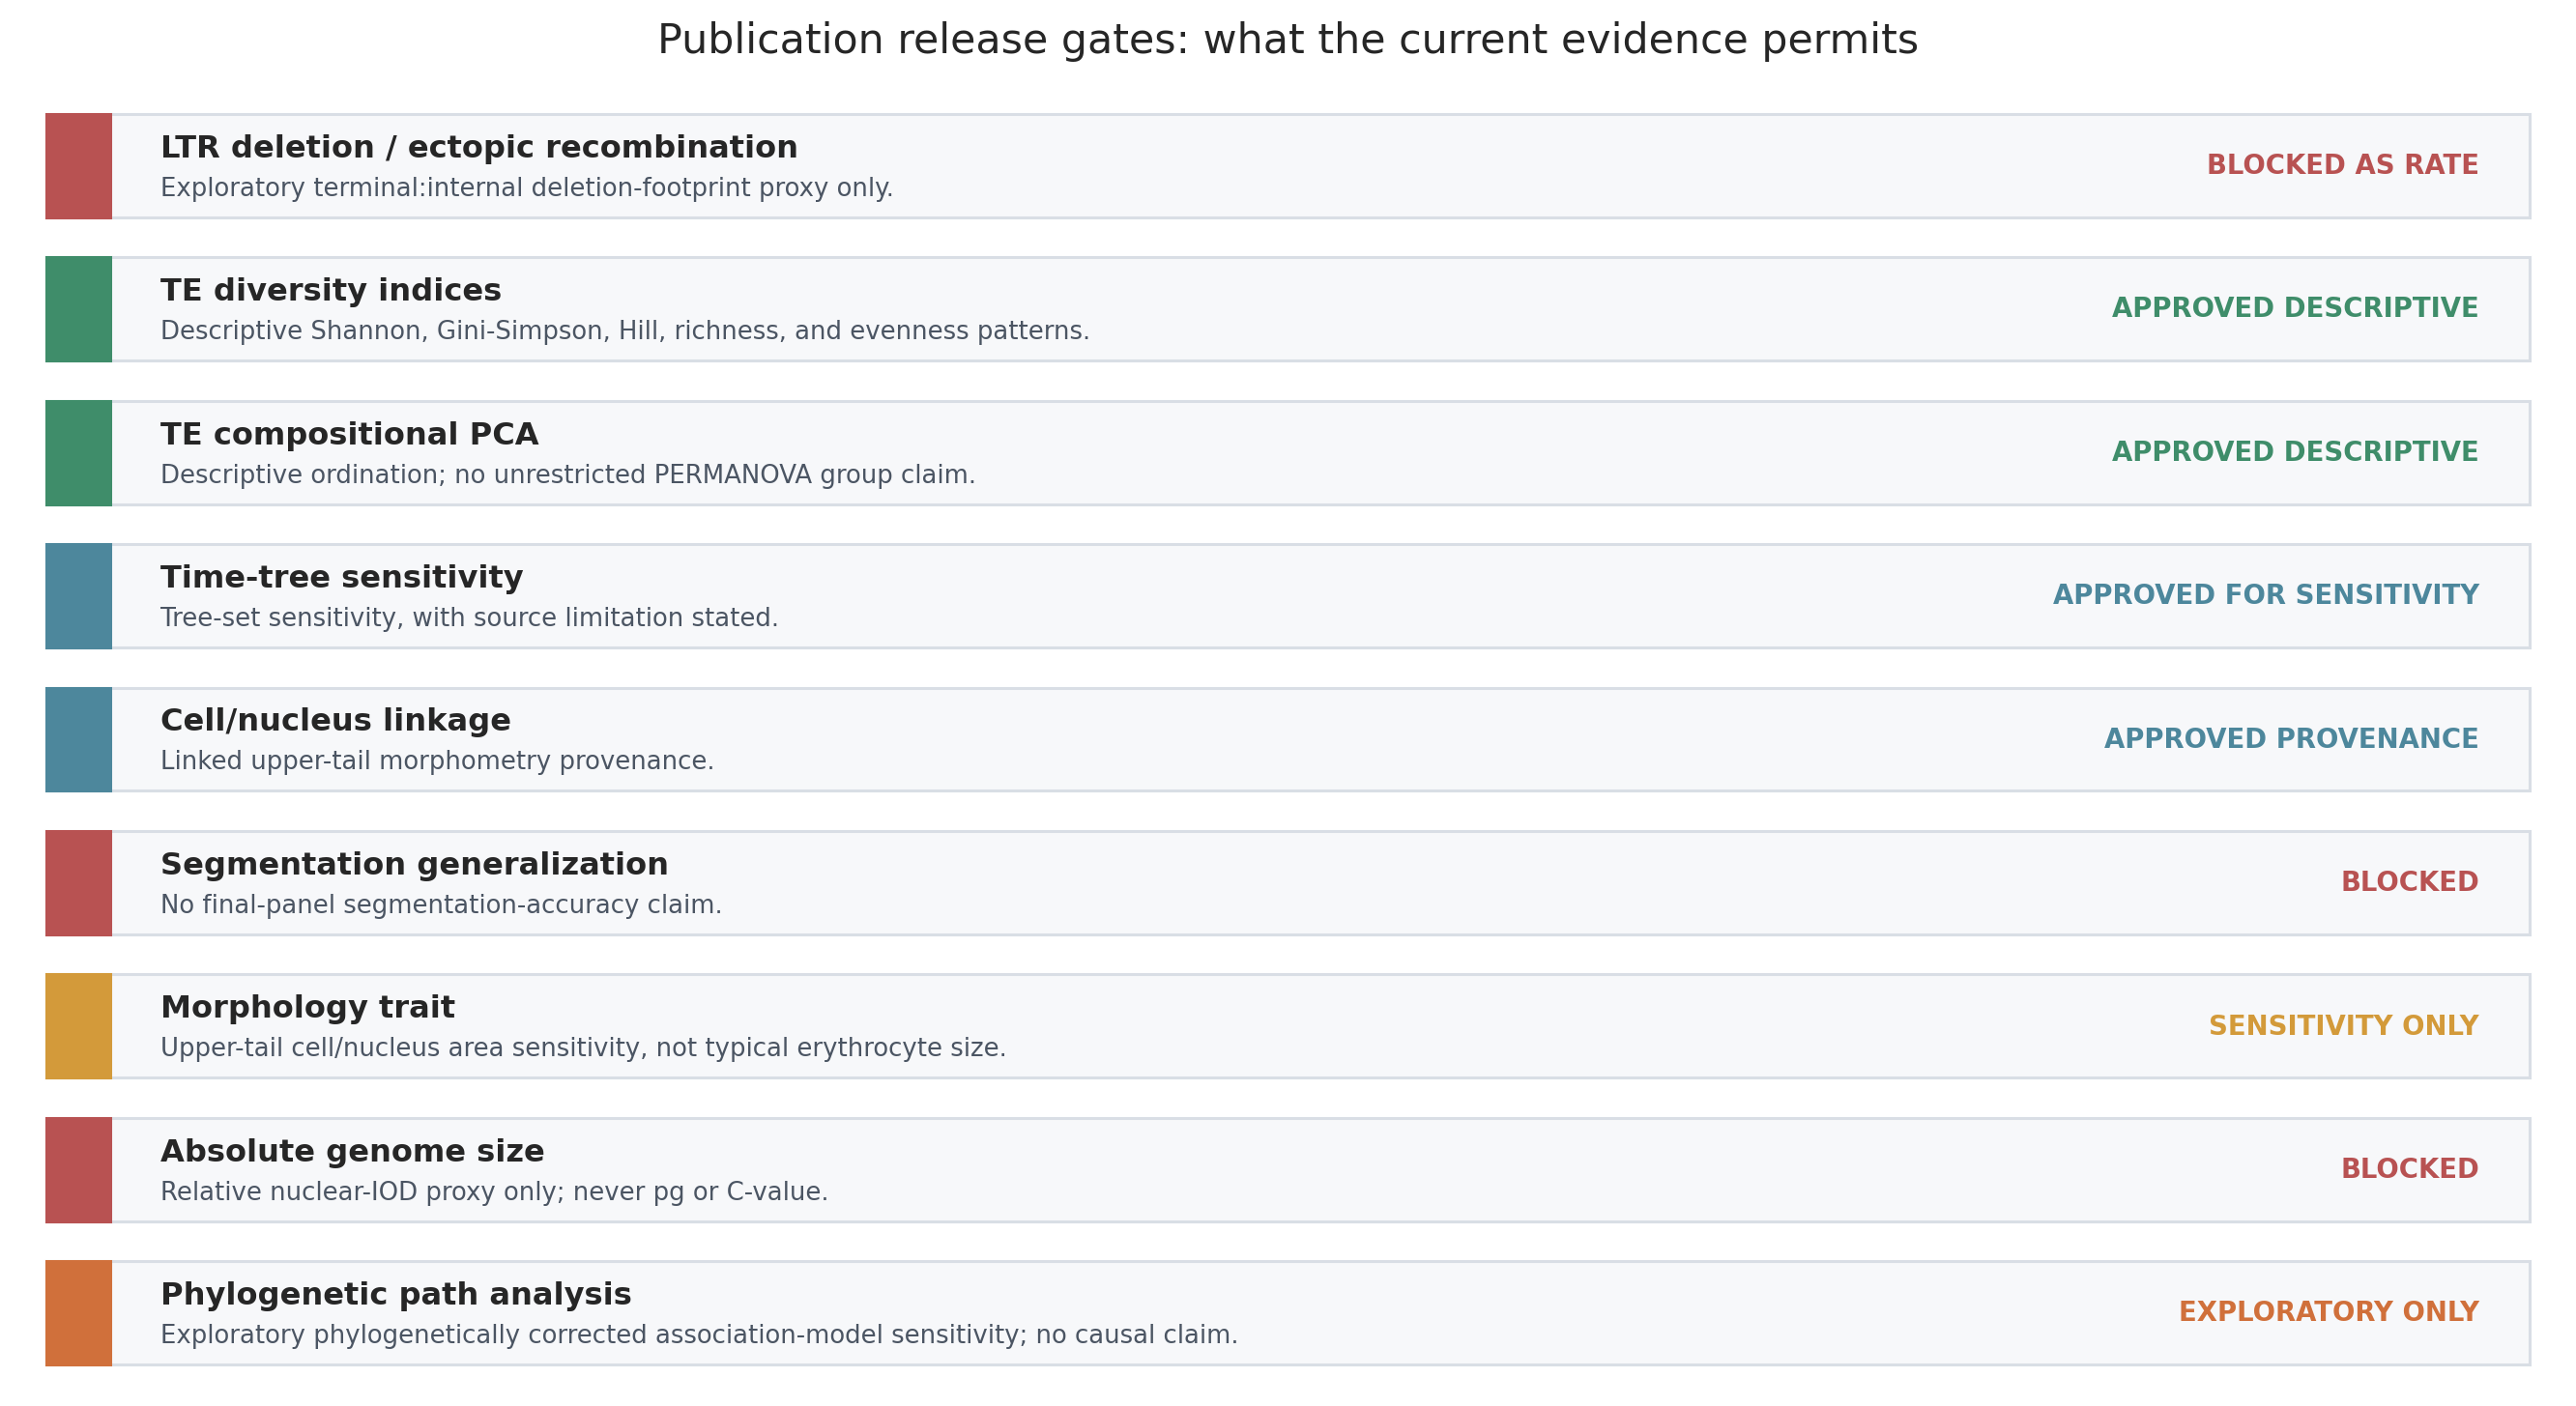

In [3]:
gates = read_csv("results/data/corrected/path_analysis/publication_release_gate_matrix_analysis18_v1.csv")
display(gates[["component", "status", "evidence", "permitted_language"]])
show_figure("results/figures/corrected/path_analysis/publication_release_gate_matrix_analysis18_v1.png")

## Candidate DAGs, global fit, model weights, and edge estimates

,fit_id,family,phase,tree_id,morphology_estimator,iod_subset,omitted_species,n_species,rank,model,k,q,C,p,CICc,delta_CICc,l,w,global_fit_pass,finite_ranking_row,release_gate_status,winner_claim_allowed_by_ranking_gate,absolute_genome_size_used,publication_claim_allowed,warning_count,model_label
0,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,1,te_evenness_chain,6,9,7.950369,7.889967e-01,48.450369,0.000000,1.000000e+00,9.984025e-01,True,True,supported_unique_top_model,True,False,False,14,LTR → evenness → IOD → nucleus → cell
1,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,2,iod_morphology_only,8,7,36.914889,2.155690e-03,62.114889,13.664520,1.078418e-03,1.076695e-03,False,True,supported_unique_top_model,True,False,False,14,IOD–morphology only
2,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,3,te_additive_chain,6,9,23.482721,2.389639e-02,63.982721,15.532351,4.238311e-04,4.231540e-04,False,True,supported_unique_top_model,True,False,False,14,LTR + evenness → IOD chain
3,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,4,te_nucleus_bypass,6,9,27.605176,6.316354e-03,68.105176,19.654806,5.395268e-05,5.386649e-05,False,True,supported_unique_top_model,True,False,False,14,Evenness nucleus bypass
4,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,5,te_cell_bypass,6,9,28.020540,5.493901e-03,68.520540,20.070171,4.383468e-05,4.376465e-05,False,True,supported_unique_top_model,True,False,False,14,Evenness cell bypass
5,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,6,integrated_null,10,5,85.449536,4.578881e-10,100.449536,51.999167,5.111218e-12,5.103053e-12,False,True,supported_unique_top_model,True,False,False,14,Null
6,data__published_main__iod_morphology__image_balanced_selected50__image_qc_pass__none,iod_morphology,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,1,iod_nucleus_cell_chain,1,5,0.516649,7.723446e-01,15.516649,0.000000,1.000000e+00,9.735867e-01,True,True,supported_unique_top_model,True,False,False,4,IOD → nucleus → cell
7,data__published_main__iod_morphology__image_balanced_selected50__image_qc_pass__none,iod_morphology,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,2,iod_to_nucleus,2,4,11.749501,1.931457e-02,22.826424,7.309776,2.586440e-02,2.518123e-02,False,True,supported_unique_top_model,True,False,False,4,IOD → nucleus
8,data__published_main__iod_morphology__image_balanced_selected50__image_qc_pass__none,iod_morphology,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,3,iod_to_cell,2,4,17.865874,1.310848e-03,28.942797,13.426148,1.214924e-03,1.182834e-03,False,True,supported_unique_top_model,True,False,False,4,IOD → cell
9,data__published_main__iod_morphology__image_balanced_selected50__image_qc_pass__none,iod_morphology,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,4,morphology_null,3,3,27.585040,1.124655e-04,35.299326,19.782677,5.061116e-05,4.927435e-05,False,True,supported_unique_top_model,True,False,False,4,Null


,fit_id,family,phase,tree_id,morphology_estimator,iod_subset,omitted_species,n_species,best_model,parent,child,coefficient,std_error,approx_ci_low,approx_ci_high,interval_excludes_zero,absolute_genome_size_used,publication_claim_allowed
0,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,te_evenness_chain,even,iod,-0.431291,0.225553,-0.873376,0.010793,False,False,False
1,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,te_evenness_chain,iod,ns,0.551525,0.157379,0.243062,0.859988,True,False,False
2,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,te_evenness_chain,ltr,even,-0.654200,0.113579,-0.876815,-0.431585,True,False,False
3,data__published_main__integrated__image_balanced_selected50__image_qc_pass__none,integrated,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,te_evenness_chain,ns,cs,0.624709,0.195214,0.242089,1.007330,True,False,False
4,data__published_main__iod_morphology__image_balanced_selected50__image_qc_pass__none,iod_morphology,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,iod_nucleus_cell_chain,iod,ns,0.551525,0.157379,0.243062,0.859988,True,False,False
5,data__published_main__iod_morphology__image_balanced_selected50__image_qc_pass__none,iod_morphology,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,iod_nucleus_cell_chain,ns,cs,0.624709,0.195214,0.242089,1.007330,True,False,False
6,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,mediated_evenness,even,iod,-0.431291,0.225553,-0.873376,0.010793,False,False,False
7,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,mediated_evenness,ltr,even,-0.654200,0.113579,-0.876815,-0.431585,True,False,False


,fit_id,family,phase,tree_id,morphology_estimator,iod_subset,omitted_species,n_species,candidate_model,independence_claim,component_p,fitted_phylogenetic_parameter,component_fit_pass
1655,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,proxy_null,iod ~ ltr,0.018062,1.000000e-07,False
1656,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,proxy_null,iod ~ even,0.073933,1.000000e-07,True
1657,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,proxy_null,even ~ ltr,0.000029,1.000000e+00,False
1658,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,ltr_only,even ~ ltr,0.000029,1.000000e+00,False
1659,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,ltr_only,iod ~ ltr + even,0.654465,1.000000e-07,True
1660,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,evenness_only,even ~ ltr,0.000029,1.000000e+00,False
1661,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,evenness_only,iod ~ even + ltr,0.118251,1.000000e-07,True
1662,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,additive_composition,even ~ ltr,0.000029,1.000000e+00,False
1663,data__published_main__te_iod__image_balanced_selected50__image_qc_pass__none,te_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,18,mediated_evenness,iod ~ even + ltr,0.118251,1.000000e-07,True
1664,data__published_main__terminal_internal_iod__image_balanced_selected50__image_qc_pass__none,terminal_internal_iod,data,published_main,image_balanced_selected50,image_qc_pass,NaN,16,proxy_null,iod ~ ti,0.436651,1.000000e-07,True


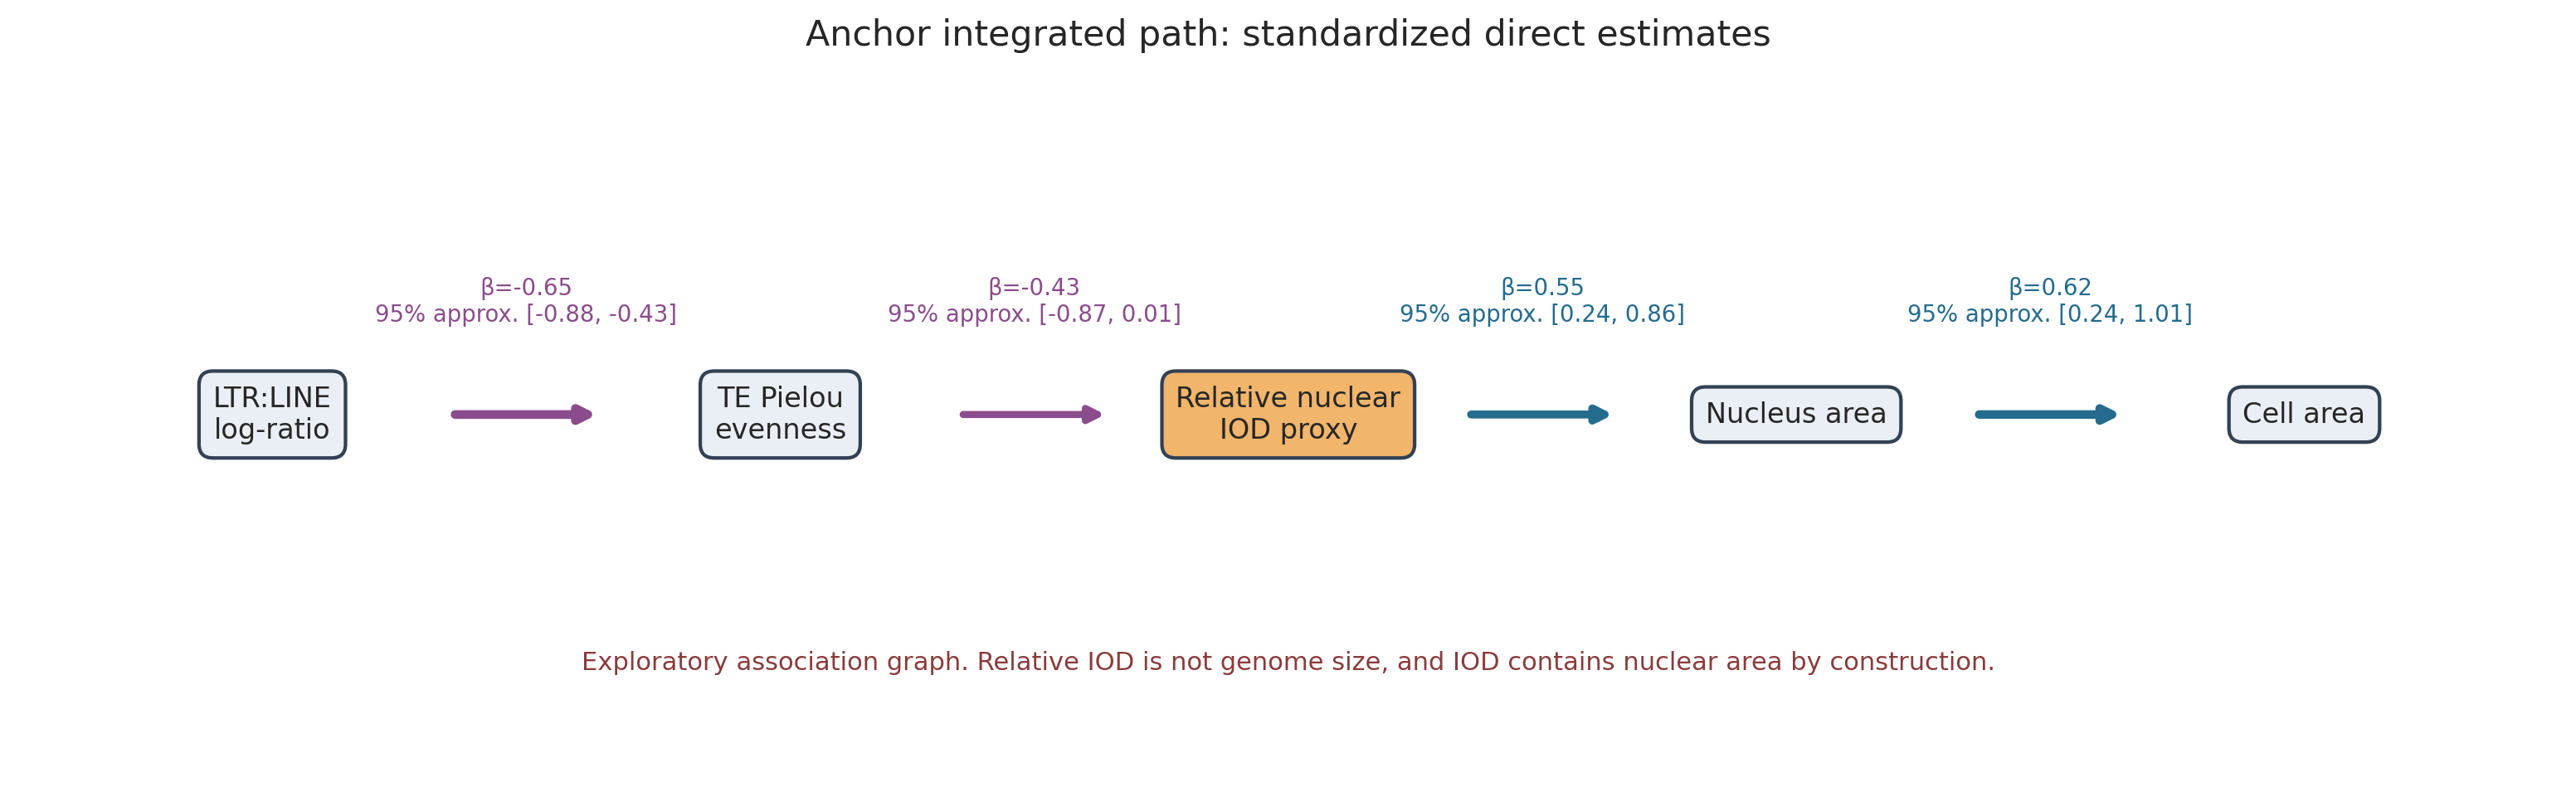

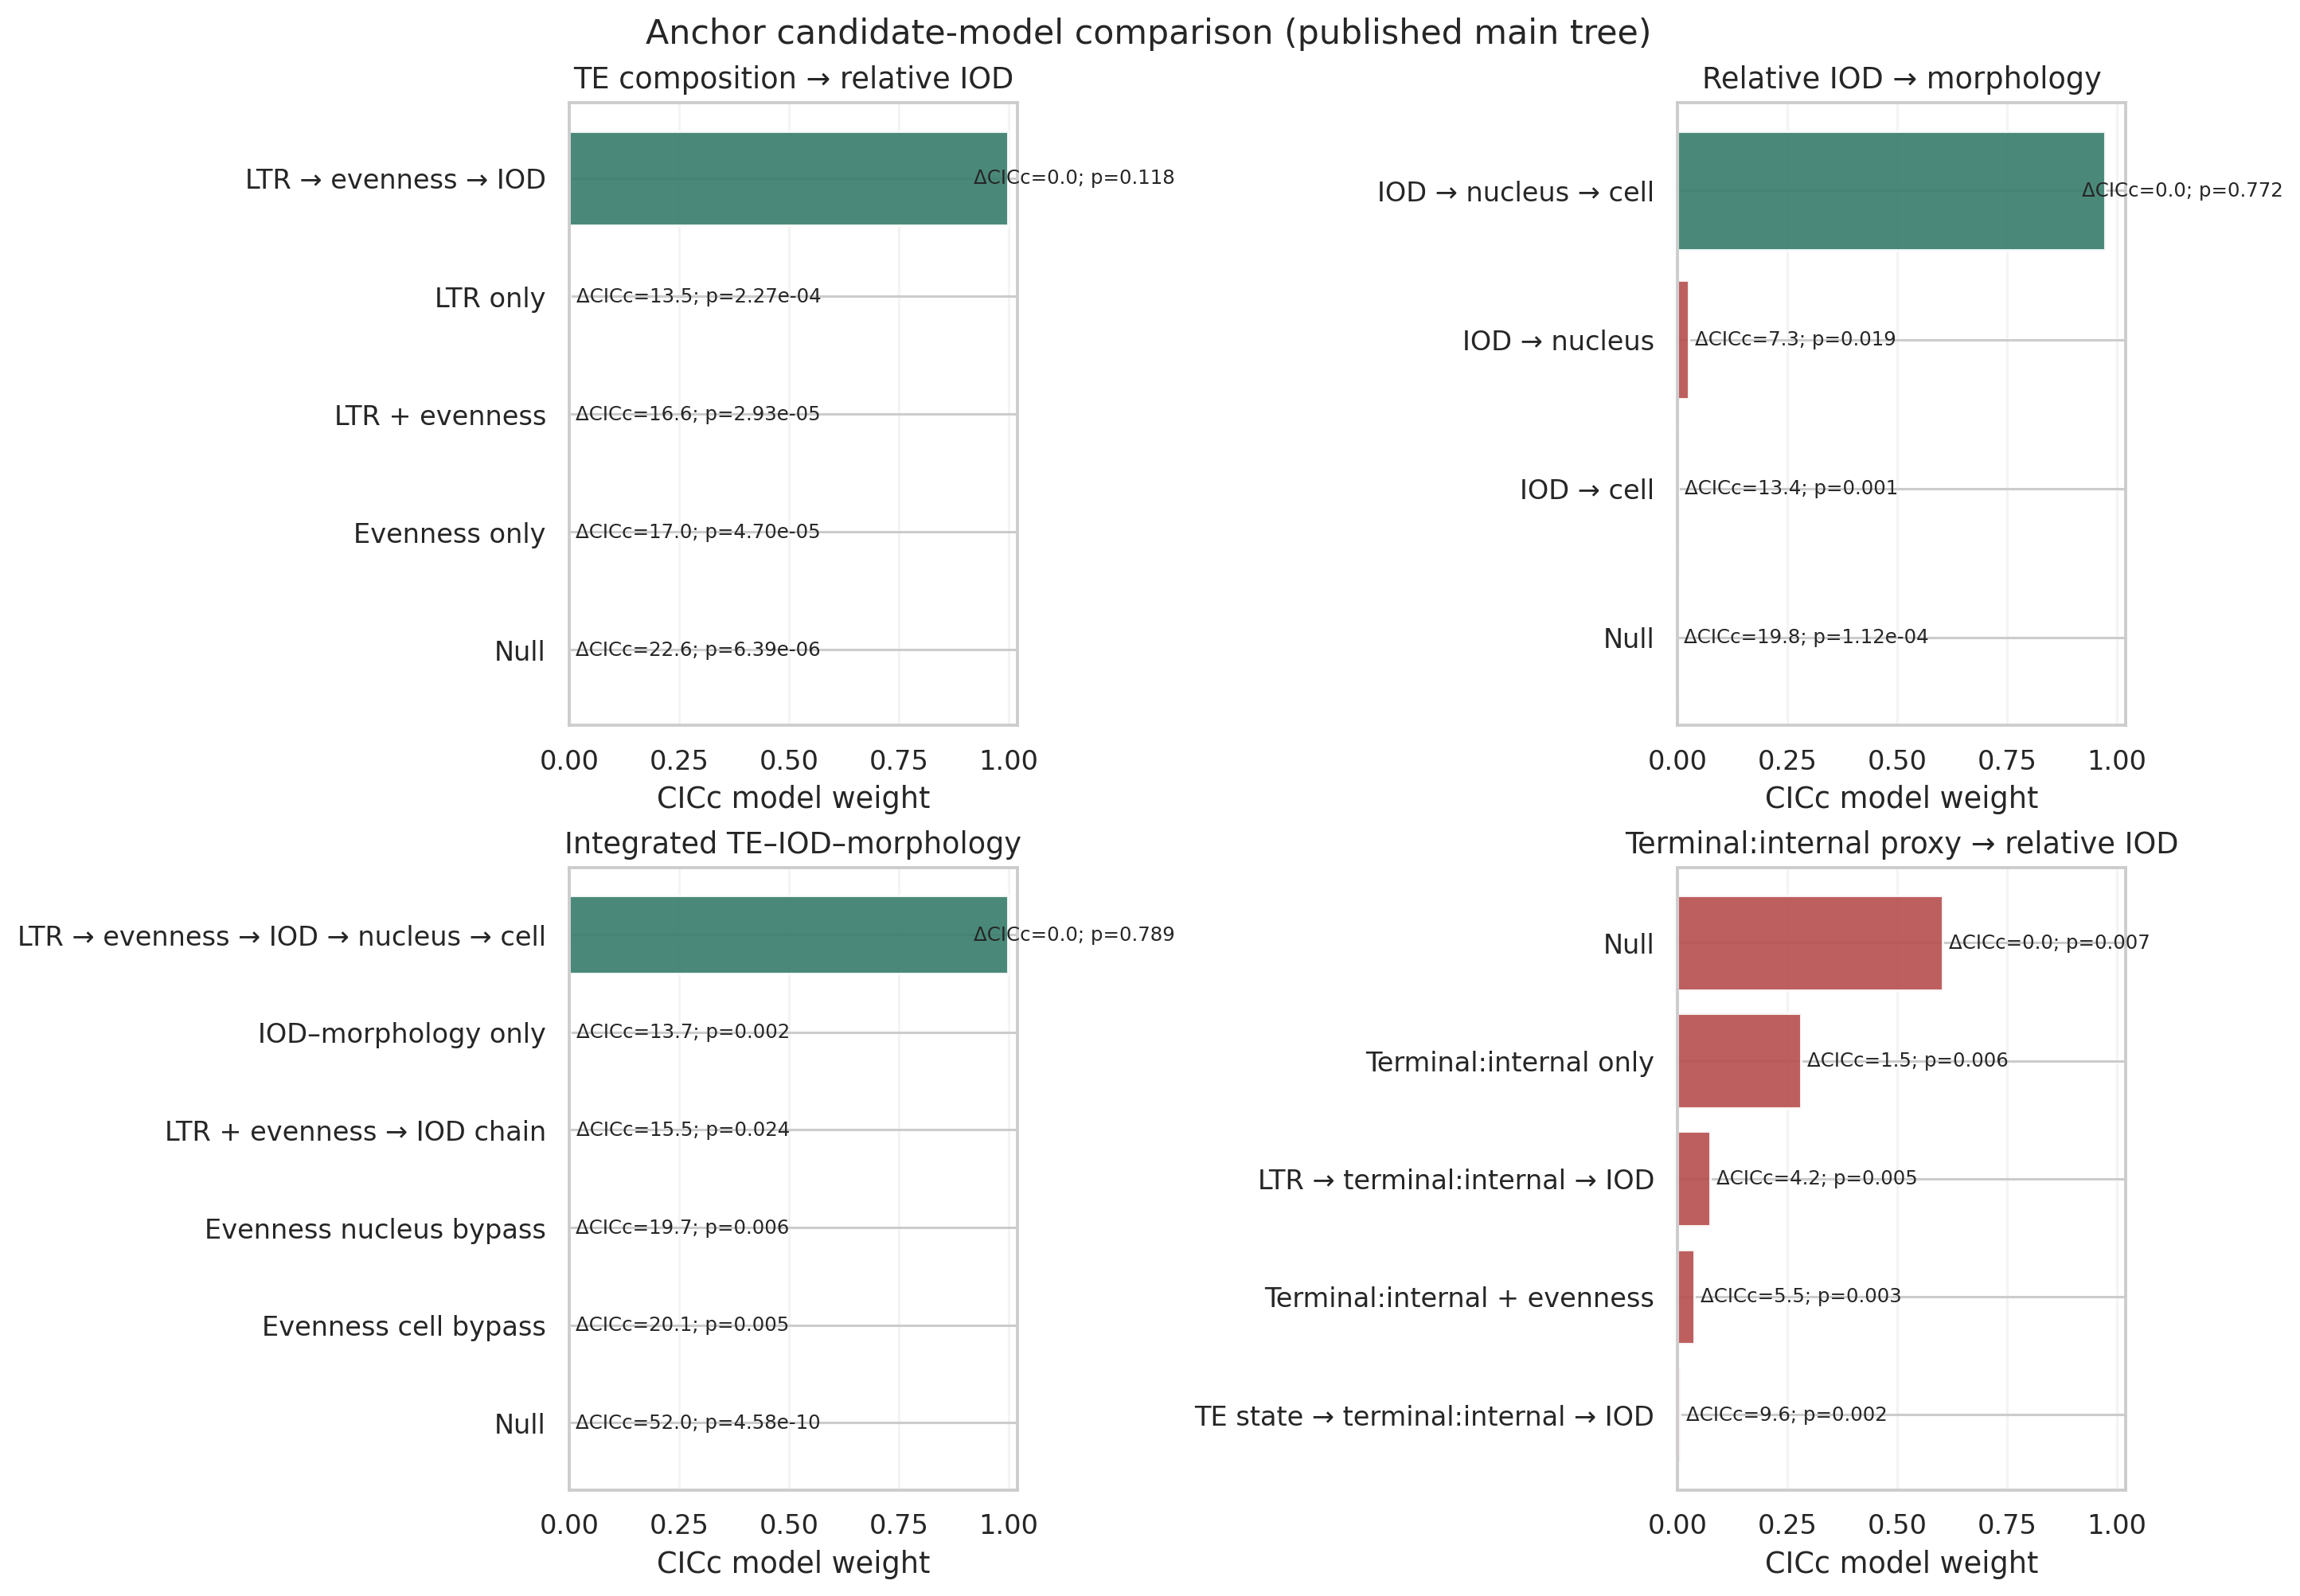

In [4]:
models = read_csv("results/data/corrected/path_analysis/corrected_path_anchor_model_comparison_analysis18_v1.csv")
edges = read_csv("results/data/corrected/path_analysis/corrected_path_anchor_edges_analysis18_v1.csv")
basis = read_csv("results/data/corrected/path_analysis/corrected_path_data_sensitivity_basis_sets_analysis18_v1.csv")
display(models)
display(edges)
display(basis[(basis.tree_id == "published_main") & (basis.morphology_estimator == "image_balanced_selected50") & (basis.iod_subset == "image_qc_pass")])
show_figure("results/figures/corrected/path_analysis/corrected_path_anchor_dag_analysis18_v1.png")
show_figure("results/figures/corrected/path_analysis/corrected_path_anchor_model_comparison_analysis18_v1.png")

## Measurement, tree, and leave-one-species-out sensitivity

,phase,family,family_label,n_fits,modal_top_model,modal_top_model_label,modal_top_model_rate,global_fit_pass_rate,unique_top_gate_rate,minimum_top_weight,median_top_weight,maximum_top_weight,minimum_global_p,maximum_global_p,absolute_genome_size_used,publication_claim_allowed
0,data,integrated,Integrated TE–IOD–morphology,36,te_evenness_chain,LTR → evenness → IOD → nucleus → cell,1.0000,1.0,1.000000,0.996632,0.999488,0.999856,0.356029,0.881111,False,False
1,data,iod_morphology,Relative IOD → morphology,36,iod_nucleus_cell_chain,IOD → nucleus → cell,1.0000,1.0,0.888889,0.560617,0.968326,0.995836,0.200145,0.915959,False,False
2,data,te_iod,TE composition → relative IOD,6,mediated_evenness,LTR → evenness → IOD,1.0000,1.0,1.000000,0.998382,0.999093,0.999539,0.118251,0.145041,False,False
3,data,terminal_internal_iod,Terminal:internal proxy → relative IOD,6,proxy_null,Null,1.0000,0.0,0.000000,0.602963,0.633155,0.633744,0.005087,0.008300,False,False
4,trees,integrated,Integrated TE–IOD–morphology,201,te_evenness_chain,LTR → evenness → IOD → nucleus → cell,1.0000,1.0,1.000000,0.998403,0.998863,0.999208,0.459067,0.815740,False,False
5,trees,iod_morphology,Relative IOD → morphology,201,iod_nucleus_cell_chain,IOD → nucleus → cell,1.0000,1.0,1.000000,0.973418,0.973650,0.973996,0.772345,0.772345,False,False
6,trees,te_iod,TE composition → relative IOD,201,mediated_evenness,LTR → evenness → IOD,1.0000,1.0,1.000000,0.998382,0.998849,0.999221,0.118251,0.118251,False,False
7,trees,terminal_internal_iod,Terminal:internal proxy → relative IOD,201,proxy_null,Null,1.0000,0.0,0.000000,0.602963,0.602963,0.602963,0.005451,0.008241,False,False
8,loo,integrated,Integrated TE–IOD–morphology,18,te_evenness_chain,LTR → evenness → IOD → nucleus → cell,1.0000,1.0,0.944444,0.695355,0.992312,0.999131,0.260952,0.868594,False,False
9,loo,iod_morphology,Relative IOD → morphology,18,iod_nucleus_cell_chain,IOD → nucleus → cell,1.0000,1.0,1.000000,0.922368,0.956943,0.988587,0.529493,0.986062,False,False


,family,best_model,parent,child,n_trees,coefficient_median,coefficient_q025,coefficient_q975,minimum_coefficient,maximum_coefficient,sign_stability_rate
0,integrated,te_evenness_chain,even,iod,201,-0.431291,-0.431291,-0.431291,-0.431291,-0.431291,1.0
1,integrated,te_evenness_chain,iod,ns,201,0.555230,0.546321,0.565581,0.538713,0.570689,1.0
2,integrated,te_evenness_chain,ltr,even,201,-0.655804,-0.659190,-0.651216,-0.659977,-0.643593,1.0
3,integrated,te_evenness_chain,ns,cs,201,0.624709,0.624709,0.624709,0.624709,0.624709,1.0
4,iod_morphology,iod_nucleus_cell_chain,iod,ns,201,0.555230,0.546321,0.565581,0.538713,0.570689,1.0
5,iod_morphology,iod_nucleus_cell_chain,ns,cs,201,0.624709,0.624709,0.624709,0.624709,0.624709,1.0
6,te_iod,mediated_evenness,even,iod,201,-0.431291,-0.431291,-0.431291,-0.431291,-0.431291,1.0
7,te_iod,mediated_evenness,ltr,even,201,-0.655804,-0.659190,-0.651216,-0.659977,-0.643593,1.0


,fit_id,family,phase,tree_id,morphology_estimator,iod_subset,omitted_species,n_species,rank,model,k,q,C,p,CICc,delta_CICc,l,w,global_fit_pass,finite_ranking_row,release_gate_status,winner_claim_allowed_by_ranking_gate,absolute_genome_size_used,publication_claim_allowed,warning_count
0,loo__published_main__te_iod__image_balanced_selected50__image_qc_pass__amphileucus,te_iod,loo,published_main,image_balanced_selected50,image_qc_pass,amphileucus,17,1,mediated_evenness,1,5,3.439345,0.179125,18.893890,0.000000,1.000000,0.998043,True,True,supported_unique_top_model,True,False,False,4
1,loo__published_main__te_iod__image_balanced_selected50__image_qc_pass__amphileucus,te_iod,loo,published_main,image_balanced_selected50,image_qc_pass,amphileucus,17,2,ltr_only,2,4,20.856150,0.000338,32.189483,13.295593,0.001297,0.001294,False,True,supported_unique_top_model,True,False,False,4
2,loo__published_main__te_iod__image_balanced_selected50__image_qc_pass__amphileucus,te_iod,loo,published_main,image_balanced_selected50,image_qc_pass,amphileucus,17,3,evenness_only,2,4,23.319346,0.000109,34.652679,15.758788,0.000378,0.000378,False,True,supported_unique_top_model,True,False,False,4
3,loo__published_main__te_iod__image_balanced_selected50__image_qc_pass__amphileucus,te_iod,loo,published_main,image_balanced_selected50,image_qc_pass,amphileucus,17,4,additive_composition,1,5,19.880001,0.000048,35.334546,16.440656,0.000269,0.000269,False,True,supported_unique_top_model,True,False,False,4
4,loo__published_main__te_iod__image_balanced_selected50__image_qc_pass__amphileucus,te_iod,loo,published_main,image_balanced_selected50,image_qc_pass,amphileucus,17,5,proxy_null,3,3,33.146651,0.000010,40.992805,22.098914,0.000016,0.000016,False,True,supported_unique_top_model,True,False,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,loo__published_main__terminal_internal_iod__image_balanced_selected50__image_qc_pass__welteri,terminal_internal_iod,loo,published_main,image_balanced_selected50,image_qc_pass,welteri,15,1,proxy_null,6,4,27.392597,0.006781,39.392597,0.000000,1.000000,0.647672,False,True,blocked_no_globally_supported_model,False,False,False,9
346,loo__published_main__terminal_internal_iod__image_balanced_selected50__image_qc_pass__welteri,terminal_internal_iod,loo,published_main,image_balanced_selected50,image_qc_pass,welteri,15,2,terminal_internal_only,5,5,24.607820,0.006141,41.274487,1.881890,0.390259,0.252760,False,True,blocked_no_globally_supported_model,False,False,False,9
347,loo__published_main__terminal_internal_iod__image_balanced_selected50__image_qc_pass__welteri,terminal_internal_iod,loo,published_main,image_balanced_selected50,image_qc_pass,welteri,15,3,ltr_terminal_internal_chain,4,6,22.065697,0.004796,44.565697,5.173100,0.075279,0.048756,False,True,blocked_no_globally_supported_model,False,False,False,9
348,loo__published_main__terminal_internal_iod__image_balanced_selected50__image_qc_pass__welteri,terminal_internal_iod,loo,published_main,image_balanced_selected50,image_qc_pass,welteri,15,4,terminal_internal_evenness_additive,4,6,22.069902,0.004788,44.569902,5.177305,0.075121,0.048654,False,True,blocked_no_globally_supported_model,False,False,False,9


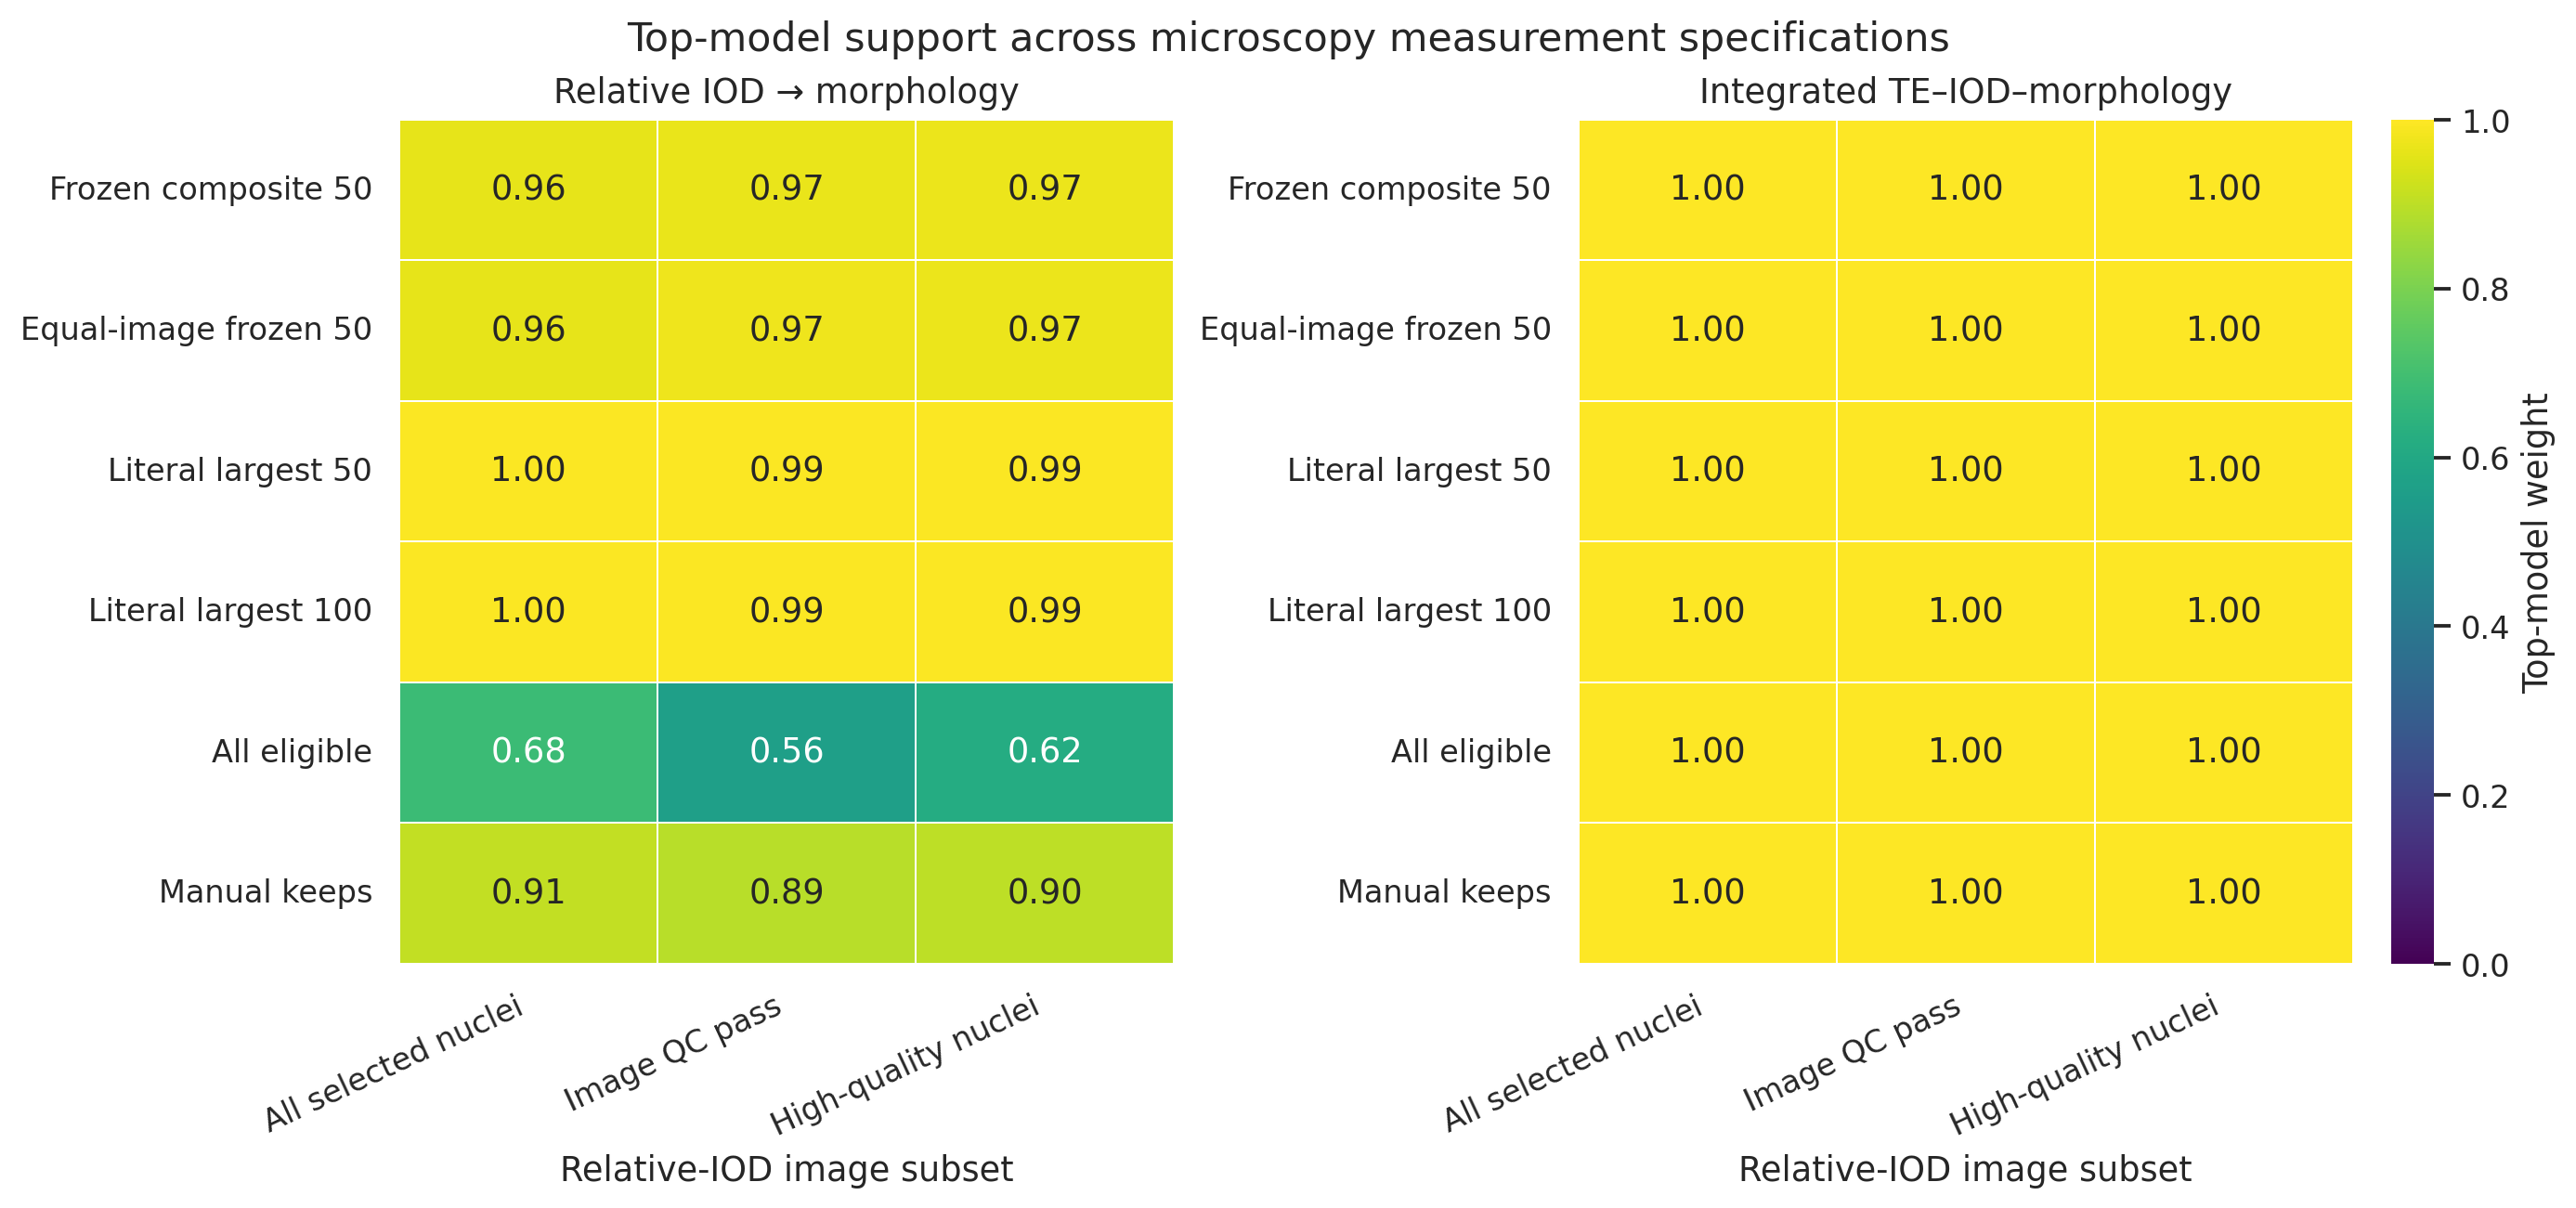

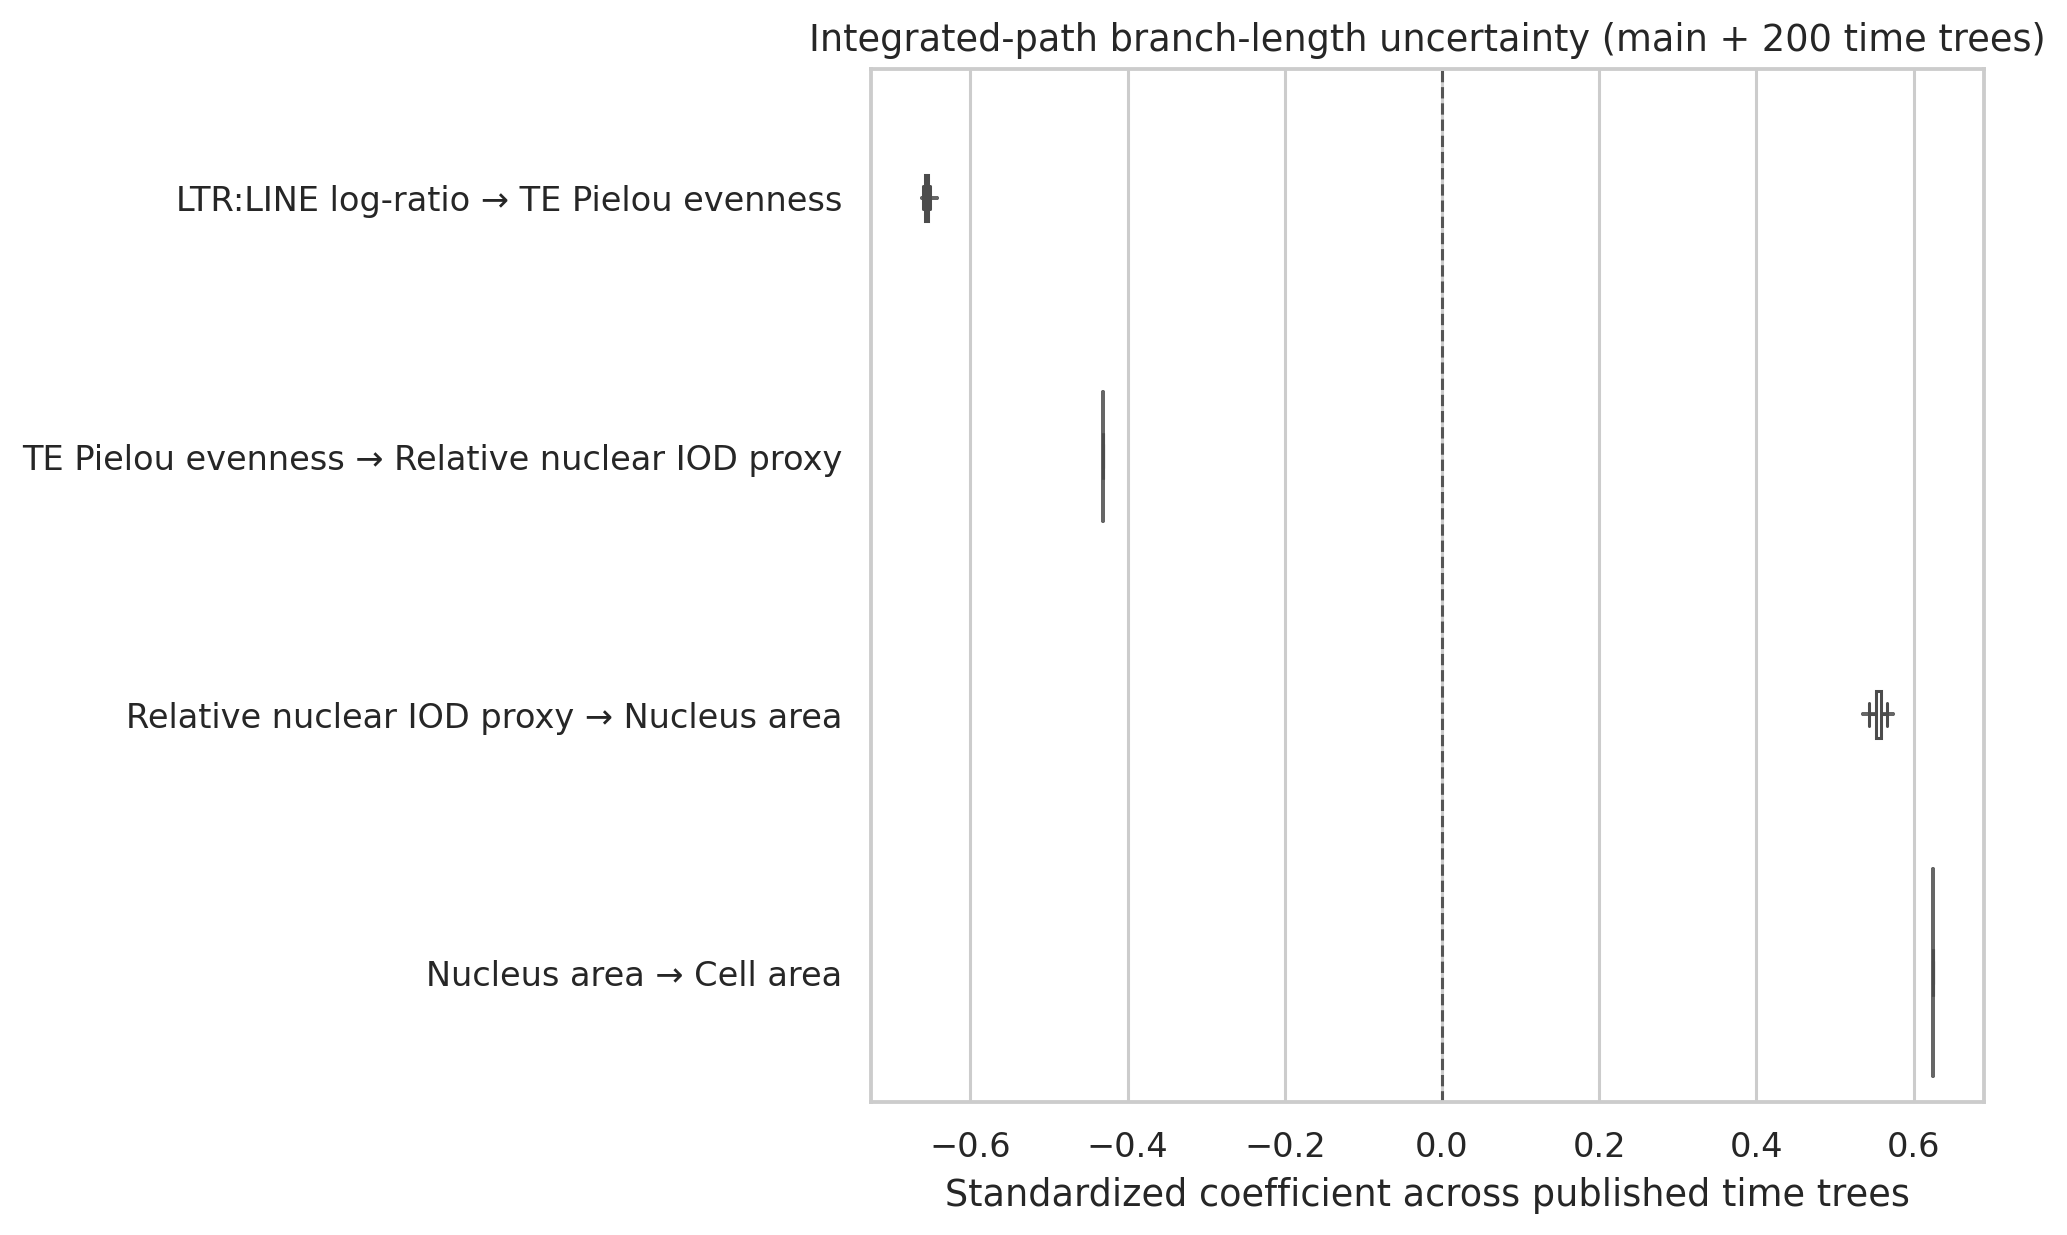

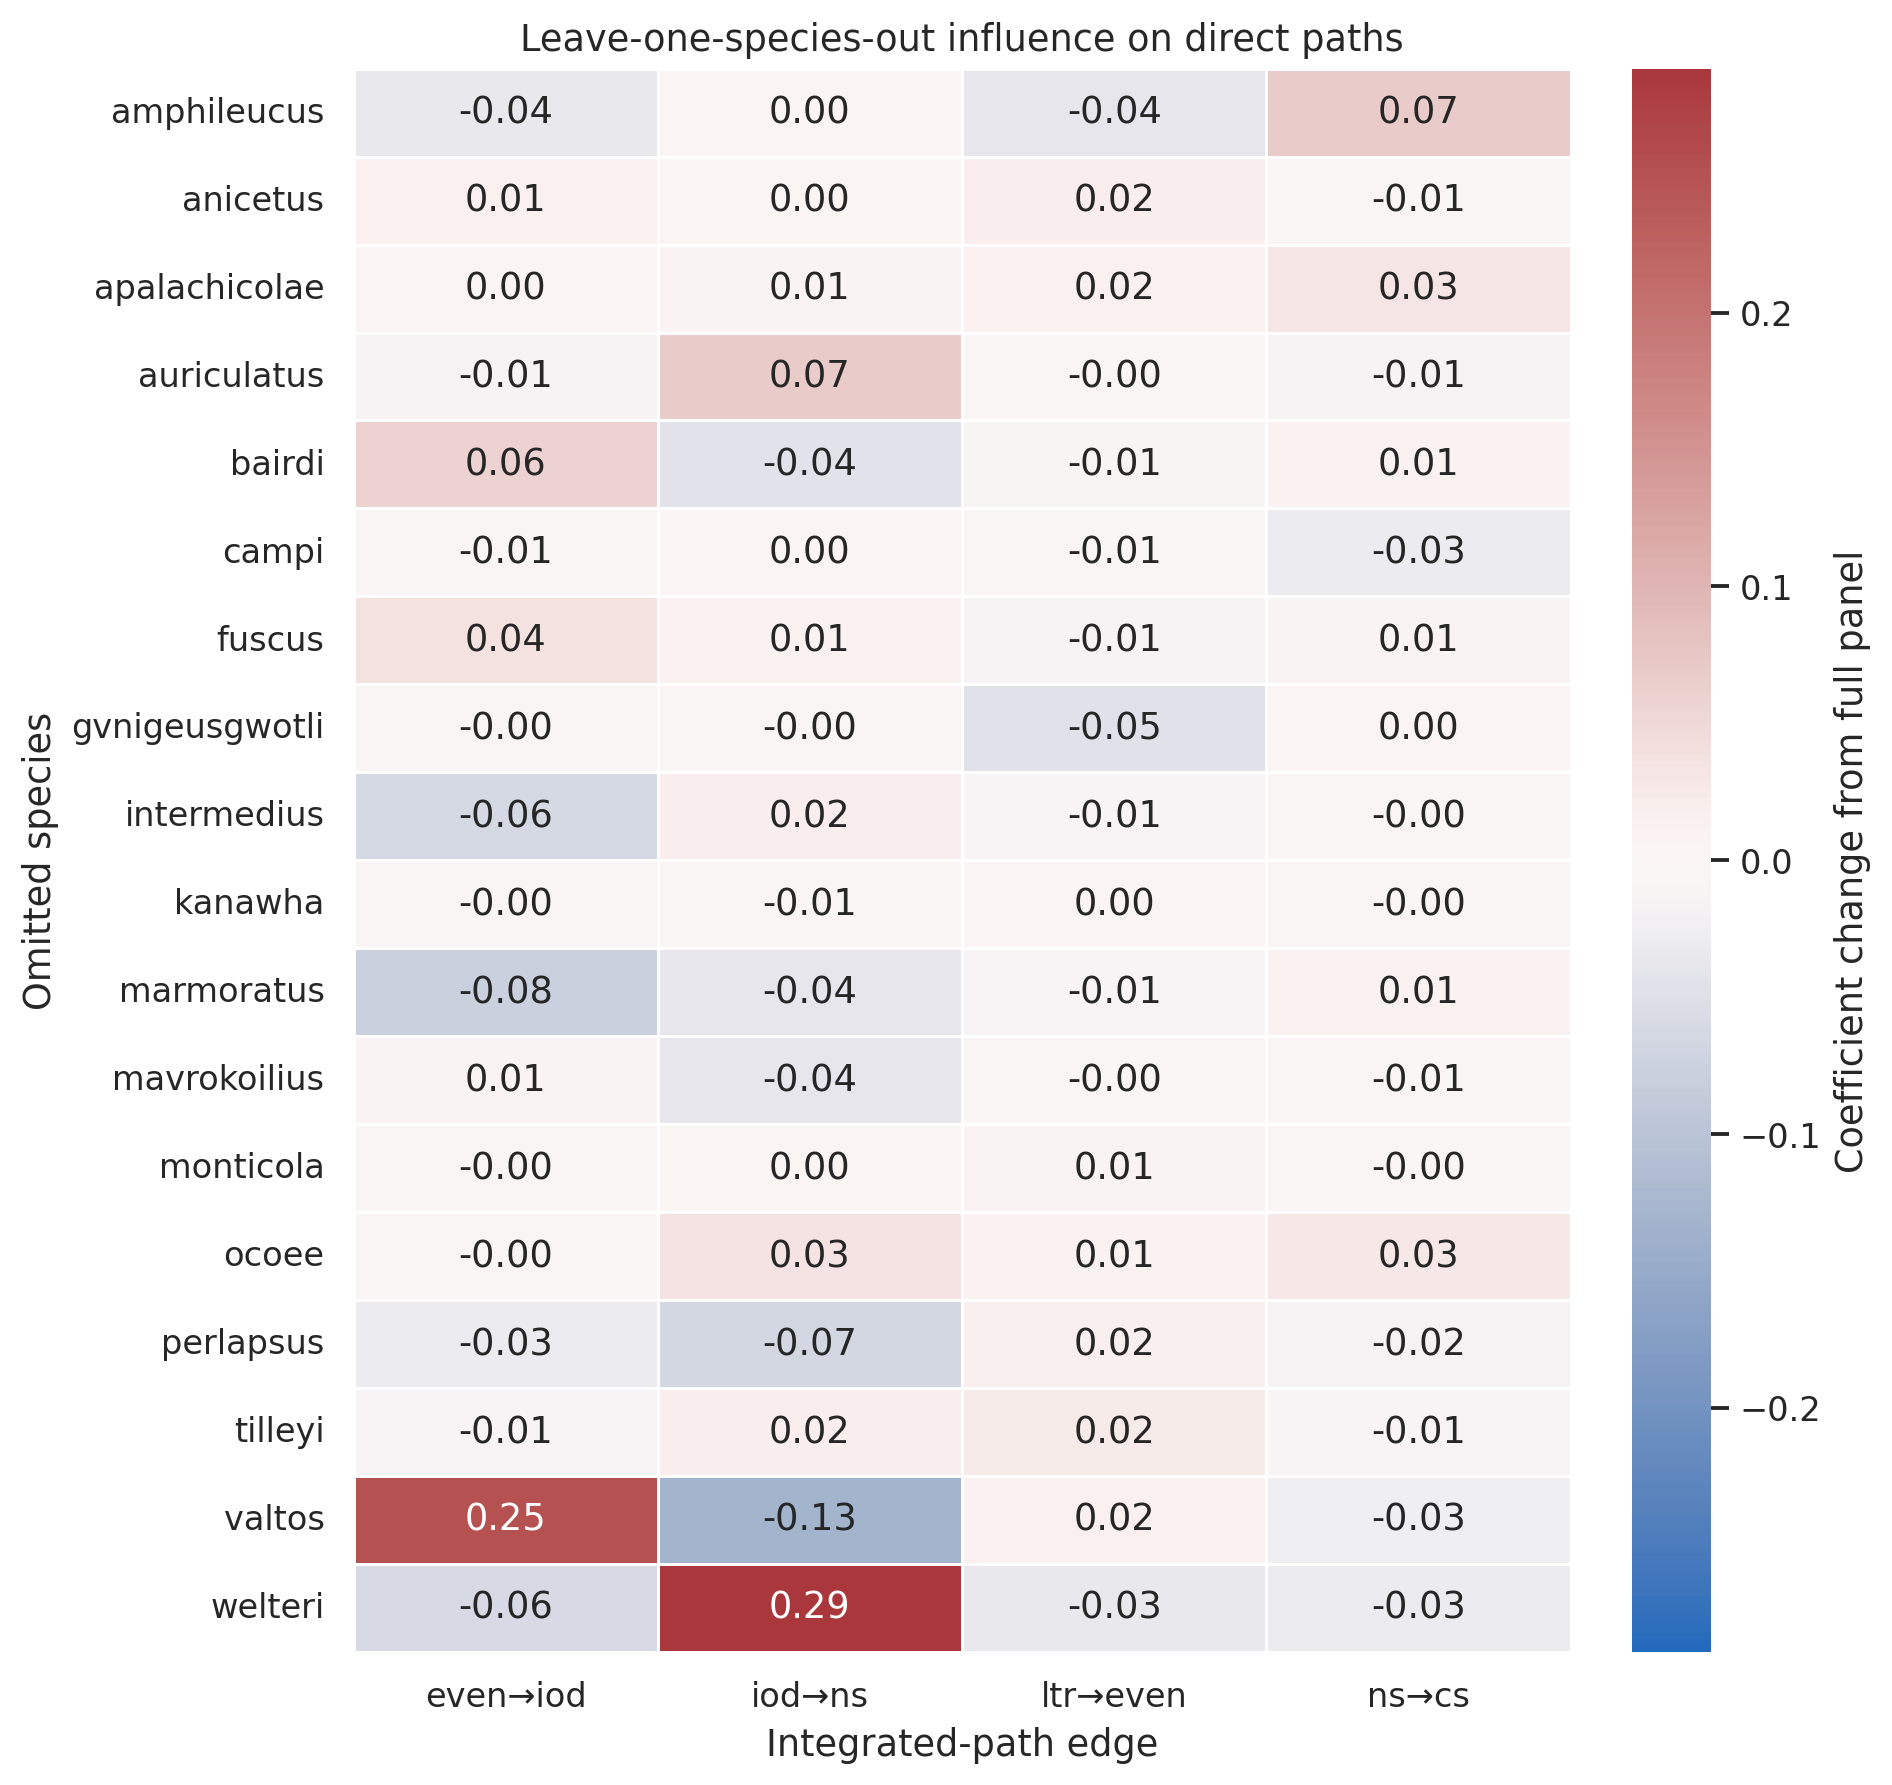

In [5]:
for table in [
    "results/data/corrected/path_analysis/corrected_path_model_stability_analysis18_v1.csv",
    "results/data/corrected/path_analysis/corrected_path_tree_edge_uncertainty_analysis18_v1.csv",
    "results/data/corrected/path_analysis/corrected_path_leave_one_out_rankings_analysis18_v1.csv",
]:
    display(read_csv(table))
for figure in [
    "results/figures/corrected/path_analysis/corrected_path_measurement_model_weights_analysis18_v1.png",
    "results/figures/corrected/path_analysis/corrected_path_tree_uncertainty_analysis18_v1.png",
    "results/figures/corrected/path_analysis/corrected_path_leave_one_out_influence_analysis18_v1.png",
]:
    show_figure(figure)

## Actual-tree calibration

,family,scenario,effect_scale,n_attempted,n_successful,n_failures,modal_top_model,modal_top_model_rate,expected_model_top_rate,expected_unique_supported_rate,false_nonnull_top_rate,false_supported_nonnull_rate,false_unique_nonnull_rate,primary_calibration_rate,primary_rate_ci_low,primary_rate_ci_high,mean_top_weight,top_global_fit_rate
0,integrated,independent_null,0.0,200,200,0,integrated_null,0.860,0.860,0.675,0.120,0.120,0.095,0.095,0.061663,0.143603,0.891997,0.850
1,integrated,observed_chain,0.5,100,100,0,integrated_null,0.620,0.100,0.100,0.000,0.000,0.000,0.100,0.055229,0.174367,0.785624,0.830
2,integrated,observed_chain,1.0,100,100,0,te_evenness_chain,0.620,0.620,0.500,0.000,0.000,0.000,0.500,0.403830,0.596170,0.807007,0.790
3,integrated,observed_chain,1.5,100,100,0,te_evenness_chain,1.000,1.000,0.810,0.000,0.000,0.000,0.810,0.722210,0.874853,1.000000,0.810
4,iod_morphology,independent_null,0.0,200,200,0,morphology_null,0.540,0.540,0.180,0.455,0.455,0.200,0.200,0.150451,0.260856,0.574563,0.995
5,iod_morphology,observed_chain,0.5,100,100,0,iod_nucleus_cell_chain,0.330,0.330,0.190,0.000,0.000,0.000,0.190,0.125147,0.277790,0.624703,0.940
6,iod_morphology,observed_chain,1.0,100,100,0,iod_nucleus_cell_chain,0.930,0.930,0.810,0.000,0.000,0.000,0.810,0.722210,0.874853,0.893693,0.920
7,iod_morphology,observed_chain,1.5,100,100,0,iod_nucleus_cell_chain,1.000,1.000,0.850,0.000,0.000,0.000,0.850,0.767163,0.906941,1.000000,0.850
8,te_iod,independent_null,0.0,200,200,0,proxy_null,0.505,0.505,0.215,0.495,0.495,0.190,0.190,0.141671,0.250014,0.529295,1.000
9,te_iod,observed_chain,0.5,100,100,0,proxy_null,0.430,0.300,0.190,0.000,0.000,0.000,0.190,0.125147,0.277790,0.563483,0.970


,family,scenario,effect_scale,parent,child,true_coefficient,n_successful,mean_estimated_coefficient,mean_bias,rmse,interval_coverage_rate,mean_interval_width
0,integrated,observed_chain,0.5,even,iod,-0.215646,100,-0.255314,-0.039669,0.256765,0.88,0.875381
1,integrated,observed_chain,0.5,iod,ns,0.275763,100,0.263926,-0.011836,0.255969,0.86,0.870348
2,integrated,observed_chain,0.5,ltr,even,-0.327100,100,-0.361372,-0.034272,0.230166,0.93,0.847388
3,integrated,observed_chain,0.5,ns,cs,0.312355,100,0.295326,-0.017029,0.236545,0.94,0.881511
4,integrated,observed_chain,1.0,even,iod,-0.431291,100,-0.411042,0.020249,0.182276,0.97,0.811224
5,integrated,observed_chain,1.0,iod,ns,0.551525,100,0.529446,-0.022079,0.172584,0.98,0.764953
6,integrated,observed_chain,1.0,ltr,even,-0.654200,100,-0.631930,0.022270,0.138820,0.99,0.711941
7,integrated,observed_chain,1.0,ns,cs,0.624709,100,0.626343,0.001634,0.152190,0.99,0.718842
8,integrated,observed_chain,1.5,even,iod,-0.646937,100,-0.654329,-0.007392,0.134292,0.99,0.709072
9,integrated,observed_chain,1.5,iod,ns,0.827288,100,0.843266,0.015978,0.091259,0.99,0.528376


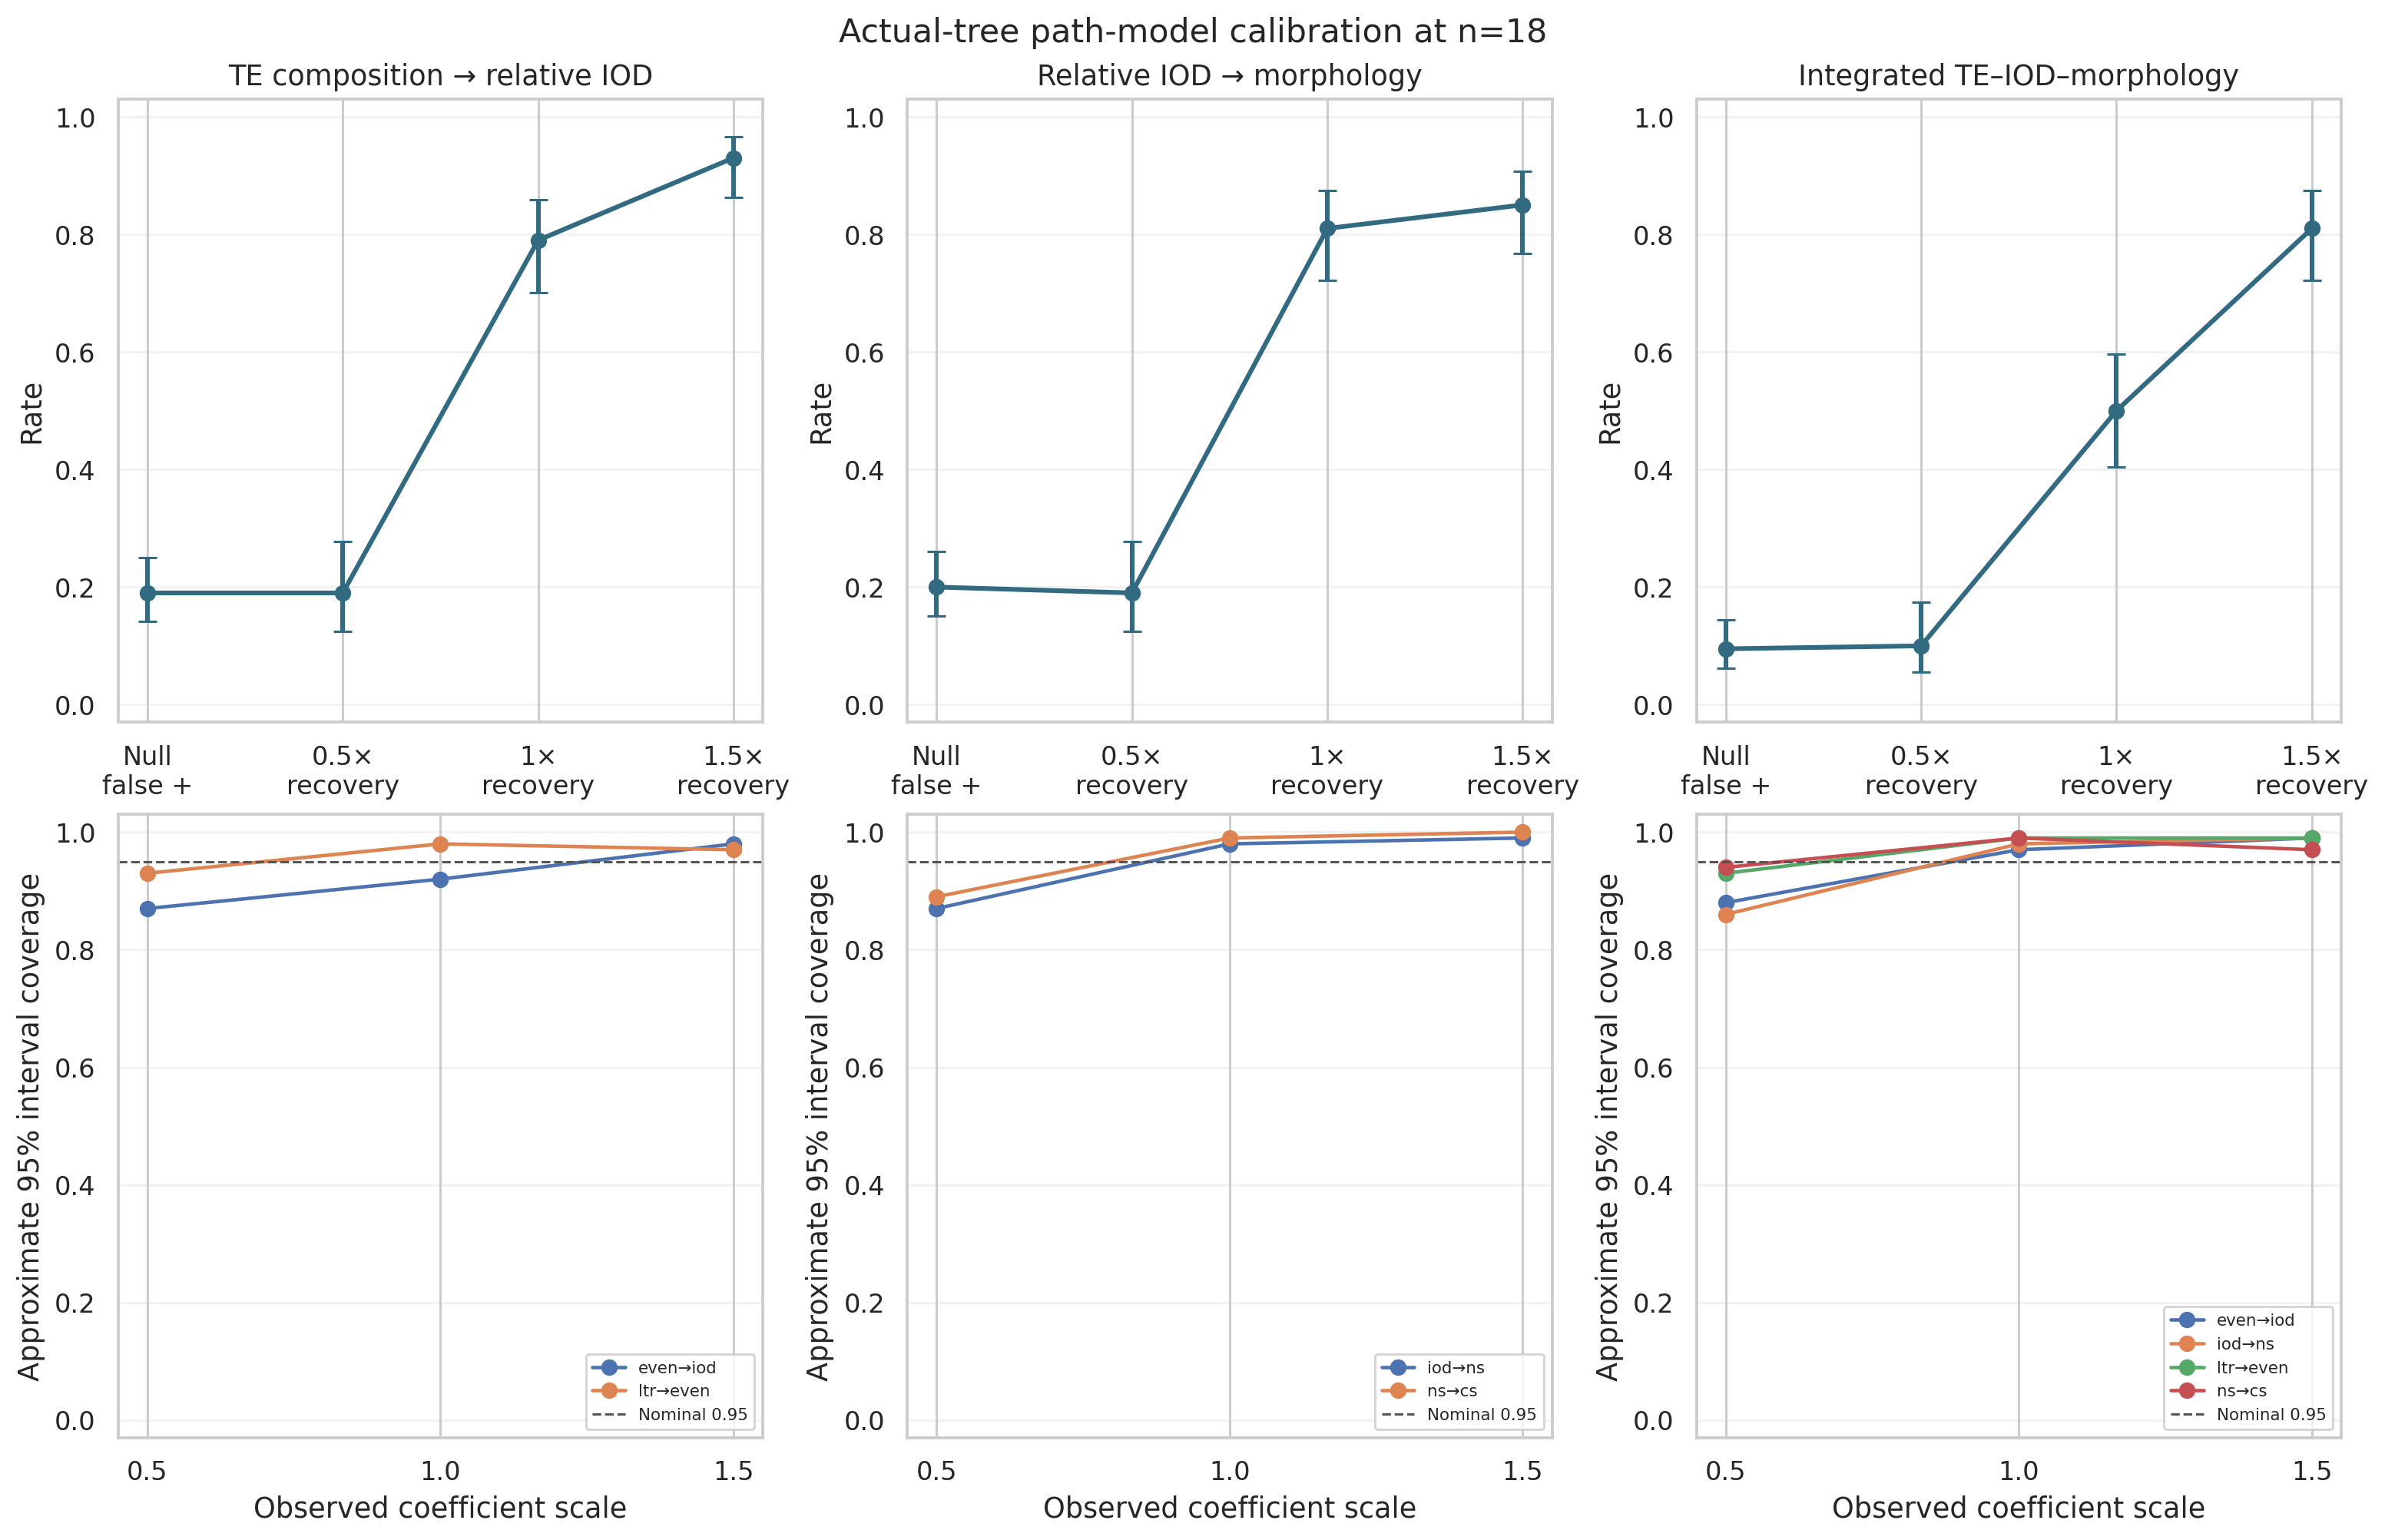

In [6]:
simulation = read_csv("results/data/corrected/path_analysis/corrected_path_simulation_calibration_analysis18_v1.csv")
edge_calibration = read_csv("results/data/corrected/path_analysis/corrected_path_simulation_edge_calibration_analysis18_v1.csv")
display(simulation)
display(edge_calibration)
show_figure("results/figures/corrected/path_analysis/corrected_path_simulation_calibration_analysis18_v1.png")

In [7]:
source_files = pd.DataFrame([{'role': 'corrected input builder', 'path': 'scripts/processing/build_corrected_path_inputs.py'}, {'role': 'path audit runner', 'path': 'scripts/processing/audit_corrected_path_models.R'}, {'role': 'path scaffold', 'path': 'path_analysis/scripts/path_model_scaffold.R'}, {'role': 'candidate model record', 'path': 'path_analysis/CANDIDATE_MODELS.md'}])
source_files["resolved_path"] = source_files.path.map(lambda value: str(resolve_artifact(value).relative_to(ROOT)))
source_files["exists"] = source_files.path.map(lambda value: resolve_artifact(value).exists())
display(source_files)
if not source_files.exists.all():
    raise FileNotFoundError(source_files.loc[~source_files.exists, "path"].tolist())

,role,path,resolved_path,exists
0,corrected input builder,scripts/processing/build_corrected_path_inputs.py,scripts/processing/build_corrected_path_inputs.py,True
1,path audit runner,scripts/processing/audit_corrected_path_models.R,scripts/processing/audit_corrected_path_models.R,True
2,path scaffold,path_analysis/scripts/path_model_scaffold.R,path_analysis/scripts/path_model_scaffold.R,True
3,candidate model record,path_analysis/CANDIDATE_MODELS.md,path_analysis/CANDIDATE_MODELS.md,True


## Interpretation and review boundary

- Report global fit and CICc/model weights before discussing individual paths.
- Stability across trees, measurement choices, and species omissions is necessary
  but does not establish causality.
- Relative nuclear-IOD algebraically contains nuclear area, so their path is partly
  mechanically coupled and cannot independently validate a nucleotypic mechanism.
- TE evenness and TE log-ratios are derived from the same closed composition.
- At n = 18, simulation calibration and uncertainty are part of the result, not
  optional supplementary detail.